In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("/home/oem/Downloads/Iris.csv")

print(data.shape)

(150, 6)


In [2]:

print("classes to predict:", data["Species"].unique())
print("features:", data.columns[1:-1].tolist())

classes to predict: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [3]:
x = data.iloc[:, 1:-1]
y = data["Species"]

display(x.shape, y.shape)

(150, 4)

(150,)

In [4]:
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier 
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state = 50, test_size = 0.25)

In [5]:
classifier = DecisionTreeClassifier() 
classifier.fit(xtrain,ytrain) 
DecisionTreeClassifier() 
y_pred = classifier.predict(xtest) 
from sklearn.metrics import accuracy_score 
print('Accuracy on train data using Gini:',accuracy_score(ytrain,classifier.predict(xtrain))) 
print('Accuracy on test data using Gini:',accuracy_score(ytest,y_pred))

Accuracy on train data using Gini: 1.0
Accuracy on test data using Gini: 0.9473684210526315


In [6]:
classifier_entropy = DecisionTreeClassifier(criterion ='entropy') 
classifier_entropy.fit(xtrain,ytrain) 
y_pred_entropy = classifier_entropy.predict(xtest) 
print('Accuracy on train data using entropy', 
      accuracy_score(ytrain,classifier.predict(xtrain))) 
print('Accuracy on test data using entropy', 
      accuracy_score(ytest,y_pred_entropy))

Accuracy on train data using entropy 1.0
Accuracy on test data using entropy 0.9473684210526315


In [7]:
classifier_entropy1 = DecisionTreeClassifier(criterion = 'entropy', min_samples_split=50) 

In [8]:
classifier_entropy1.fit(xtrain,ytrain) 
y_pred_entropy1 = classifier_entropy1.predict(xtest) 
print('Accuracy on train data using entropy', 
      accuracy_score(y_true=ytrain, y_pred= classifier_entropy1.predict(xtrain))) 
print('Accuracy on test data using entropy', 
      accuracy_score(y_true = ytest, y_pred = y_pred_entropy1))   

Accuracy on train data using entropy 0.9642857142857143
Accuracy on test data using entropy 0.9473684210526315


In [9]:
from sklearn.tree import export_graphviz     
from six import StringIO   

In [10]:
from IPython.display import Image  

In [11]:
%pip install pydotplus

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pydotplus

In [15]:
from io import StringIO

dot_data = StringIO()

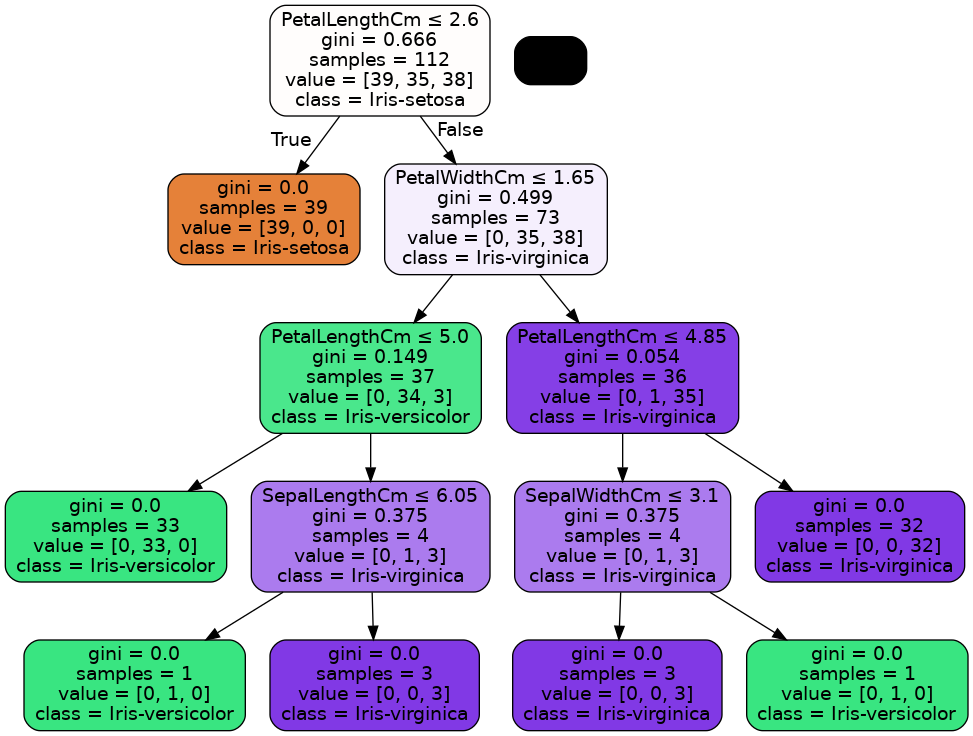

In [17]:
export_graphviz(classifier, out_file=dot_data, filled=True,
                rounded=True, special_characters=True,
                feature_names=x.columns,
                class_names=y.unique())

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())